# Thread Implementation Analysis Report

## Methods

In this lab, I refactored the code to use an additonal thread specifically for the heartbeat LED, instead of a kernel timer. Additonally, I changed the duty cycle heartbeat to have a 25% duty cycle (i.e., on for 250 ms, off for 750 ms), instead of a 50% duty cycle, at 1 Hz. 

In this lab, I used the oscilliscope to verify my chnages in the code for thread creation for the heartbeat LED. I connected the probes to the LED pins in the board and configured the setting to have a sample rate of 5000 samples per second and 50,000 samples were collected (10 seconds of data). The voltage signal for all LEDs ranges from 0V (LED off) - 3.3V (LED on), with some noise seen on both ends. The data was exported to a CSV file, which contains the time-voltage pairings for analysis. 

## Results

In [70]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

def load_oscilloscope_data(filename):
    df = pd.read_csv(filename, skiprows=1, names=["Time (s)", "Voltage (V)"])
    df["Time (s)"] = pd.to_numeric(df["Time (s)"], errors="coerce")
    df["Voltage (V)"] = pd.to_numeric(df["Voltage (V)"].astype(str).str.replace("+", "", regex=False), errors="coerce")
    df = df.dropna()
    return df["Time (s)"].to_numpy(), df["Voltage (V)"].to_numpy()

def detect_pulses(time, voltage, threshold=1.5, invert=False):
    if invert:
        binary_signal = (voltage < threshold).astype(int)
    else:
        binary_signal = (voltage > threshold).astype(int)
    
    rising_edges = np.where(np.diff(binary_signal) > 0)[0]
    falling_edges = np.where(np.diff(binary_signal) < 0)[0]
    
    rising_times = time[rising_edges]
    falling_times = time[falling_edges]
    
    return rising_times, falling_times

def calculate_duty_cycles(rising_times, falling_times):
    duty_cycles = []
    pulse_widths = []
    periods = []

    if len(rising_times) < 2:
        return np.array([]), np.array([]), np.array([])
    
    for i in range(len(rising_times) - 1):
        rising = rising_times[i]
        
        falling_after = falling_times[falling_times > rising]
        if len(falling_after) == 0:
            continue
        falling = falling_after[0]

        pulse_width = falling - rising
        
        period = rising_times[i + 1] - rising
        
        duty_cycle = (pulse_width / period) * 100
        
        duty_cycles.append(duty_cycle)
        pulse_widths.append(pulse_width)
        periods.append(period)
    
    return np.array(duty_cycles), np.array(pulse_widths), np.array(periods)

def calculate_statistics(data, confidence=0.95):
    if len(data) == 0:
        return None
    
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    sem = stats.sem(data)
    
    ci = stats.t.interval(confidence, len(data)-1, loc=mean, scale=sem)
    ci_range = ci[1] - mean
    
    return {
        'mean': mean,
        'std': std,
        'sem': sem,
        'ci_lower': ci[0],
        'ci_upper': ci[1],
        'ci_range': ci_range,
        'n_samples': len(data)
    }

def analyze_duty_cycle(filename, nominal_duty=25.0, nominal_freq=1.0, threshold=1.5, invert=False):
    time, voltage = load_oscilloscope_data(filename)
    print(f"Voltage range: {voltage.min():.3f} to {voltage.max():.3f} V")
    print(f"Threshold: {threshold} V")

    rising_times, falling_times = detect_pulses(time, voltage, threshold, invert)
    
    duty_cycles, pulse_widths, periods = calculate_duty_cycles(rising_times, falling_times)

    
    if len(duty_cycles) == 0:
        print("ERROR: No complete pulses detected!")
        return None
    
    duty_stats = calculate_statistics(duty_cycles)
    width_stats = calculate_statistics(pulse_widths)
    period_stats = calculate_statistics(periods)
    
    frequencies = 1.0 / periods
    freq_stats = calculate_statistics(frequencies)
    
    print(f"\nDUTY CYCLE:")
    print(f"   Mean: {duty_stats['mean']:.3f}%")
    print(f"   Std Dev: {duty_stats['std']:.3f}%")
    print(f"   95% CI: [{duty_stats['ci_lower']:.3f}%, {duty_stats['ci_upper']:.3f}%]")
    print(f"   Nominal: {nominal_duty:.3f}%")
    print(f"   Error: {duty_stats['mean'] - nominal_duty:.3f}% ({((duty_stats['mean'] - nominal_duty)/nominal_duty)*100:.2f}% relative error)")
    
    print(f"\nPULSE WIDTH (HIGH time):")
    print(f"   Mean: {width_stats['mean']*1000:.3f} ms")
    print(f"   Std Dev: {width_stats['std']*1000:.3f} ms")
    print(f"   Expected (25% of 1s): {nominal_duty/100 * (1/nominal_freq) * 1000:.3f} ms")
    print(f"\n")
    
    results = {
        'duty_cycles': duty_cycles,
        'pulse_widths': pulse_widths,
        'periods': periods,
        'frequencies': frequencies,
        'duty_stats': duty_stats,
        'width_stats': width_stats,
        'period_stats': period_stats,
        'freq_stats': freq_stats,
        # 'rising_times': rising_times,
        # 'falling_times': falling_times,
        'time': time,
        'voltage': voltage,
        'threshold': threshold
    }
    
    return results

def plot_duty_cycle_results(results, nominal_duty=25.0, nominal_freq=1.0):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.hist(results['duty_cycles'], bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    ax1.axvline(nominal_duty, color='red', linestyle='--', linewidth=2.5, 
                label=f'Nominal: {nominal_duty}%')
    ax1.axvline(results['duty_stats']['mean'], color='darkblue', linestyle='-', linewidth=2.5,
                label=f"Mean: {results['duty_stats']['mean']:.2f}%")
    ax1.axvline(results['duty_stats']['ci_lower'], color='orange', linestyle=':', linewidth=2,
                label='95% CI bounds')
    ax1.axvline(results['duty_stats']['ci_upper'], color='orange', linestyle=':', linewidth=2)
    ax1.set_xlabel('Duty Cycle (%)', fontsize=12)
    ax1.set_ylabel('Count', fontsize=12)
    ax1.set_title('Duty Cycle Distribution', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3, axis='y')

    deviation = results['duty_stats']['mean'] - nominal_duty
    error = results['duty_stats']['ci_range']
    
    ax2.errorbar(0, deviation, yerr=error, fmt='o', capsize=10, markersize=15, 
                 linewidth=3, color='coral', ecolor='darkred',
                 label=f"Measured: {results['duty_stats']['mean']:.2f}%")
    ax2.axhline(0, color='black', linestyle='--', linewidth=2, 
                label=f'Nominal: {nominal_duty}%')
    ax2.set_xlim(-0.5, 0.5)
    ax2.set_xticks([0])
    ax2.set_xticklabels(['Oscilloscope'])
    ax2.set_ylabel('Duty Cycle Deviation from Nominal (%)', fontsize=12)
    ax2.set_title('Duty Cycle Accuracy with 95% CI', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3, axis='y')
    
    fig.suptitle('PWM Duty Cycle Analysis (25% @ 1Hz)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    return fig

def create_summary_table(results, nominal_duty=25.0, nominal_freq=1.0):

    print(f"{'Parameter':<25} {'Measured':<20} {'Nominal':<15} {'Error':<15}")
    print("-" * 70)
    print(f"{'Duty Cycle':<25} {results['duty_stats']['mean']:.3f} ± {results['duty_stats']['ci_range']:.3f}%"
          f"{nominal_duty:>12.3f}%   {results['duty_stats']['mean']-nominal_duty:>10.3f}%")
    print(f"{'Pulse Width':<25} {results['width_stats']['mean']*1000:.3f} ± {results['width_stats']['ci_range']*1000:.3f} ms"
          f"{(nominal_duty/100)*(1/nominal_freq)*1000:>10.3f} ms  {(results['width_stats']['mean']-(nominal_duty/100)*(1/nominal_freq))*1000:>10.3f} ms")
    print(f"{'Frequency':<25} {results['freq_stats']['mean']:.6f} ± {results['freq_stats']['ci_range']:.6f} Hz"
          f"{nominal_freq:>10.6f} Hz {results['freq_stats']['mean']-nominal_freq:>10.6f} Hz")
    print(f"{'Period':<25} {results['period_stats']['mean']:.6f} ± {results['period_stats']['ci_range']:.6f} s"
          f"{1/nominal_freq:>10.6f} s  {results['period_stats']['mean']-(1/nominal_freq):>10.6f} s")

### Heartbeat LED Analysis

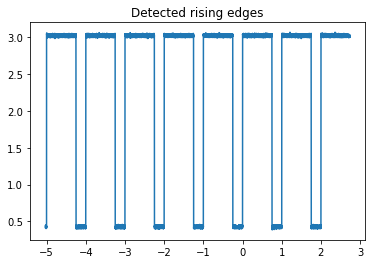

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read CSV
data = pd.read_csv("heartbeat_duty_cycle.csv")

# Convert to numpy arrays
t = data["second"].to_numpy()
v = data["Volt"].to_numpy()

v = data["Volt"].astype(str).str.replace('+', '', regex=False).astype(float)

dv = np.diff(v)

# Define thresholds
low_th = 1.0    # below this is considered low
high_th = 2.0   # above this is considered high

# Create a boolean mask for "high" state
is_high = v > high_th

# Find edges: when signal changes from low to high
edges = np.where(np.diff(is_high.astype(int)) == 1)[0]

t_edges = t[edges]
v_edges = v[edges]

plt.plot(t, v)
# plt.scatter(t_edges, v_edges, color='red')
plt.title("Detected rising edges")
plt.show()

Voltage range: 0.384 to 3.068 V
Threshold: 1.5 V

DUTY CYCLE:
   Mean: 25.008%
   Std Dev: 0.009%
   95% CI: [24.999%, 25.018%]
   Nominal: 25.000%
   Error: 0.008% (0.03% relative error)

PULSE WIDTH (HIGH time):
   Mean: 250.133 ms
   Std Dev: 0.103 ms
   Expected (25% of 1s): 250.000 ms


Parameter                 Measured             Nominal         Error          
----------------------------------------------------------------------
Duty Cycle                25.008 ± 0.009%      25.000%        0.008%
Pulse Width               250.133 ± 0.108 ms   250.000 ms       0.133 ms
Frequency                 0.999800 ± 0.000133 Hz  1.000000 Hz  -0.000200 Hz
Period                    1.000200 ± 0.000133 s  1.000000 s    0.000200 s


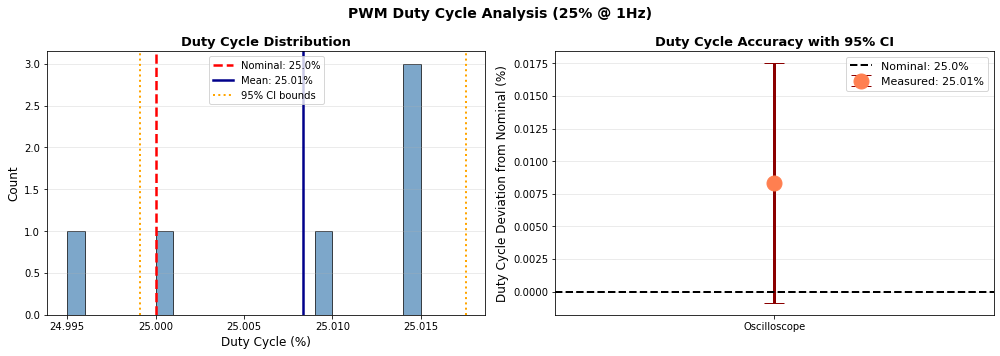

In [72]:

# ============================================
# MAIN EXECUTION
# ============================================
if __name__ == "__main__":
    # Analyze the duty cycle
    # NOTE: Set invert=True if your LED is active-low (ON = low voltage)
    # Your data shows HIGH voltage = 3V (LED ON) for short time, so invert=True
    results = analyze_duty_cycle(
        "heartbeat_duty_cycle.csv",
        nominal_duty=25.0,
        nominal_freq=1.0,
        threshold=1.5,
        invert=True  # ← SET THIS TO TRUE for your active-low LED
    )
    
    if results is not None:
        # Create visualization (only first 2 plots)
        fig = plot_duty_cycle_results(results, nominal_duty=25.0, nominal_freq=1.0)
        
        # Create summary table
        create_summary_table(results, nominal_duty=25.0, nominal_freq=1.0)
        
        plt.show()
    else:
        print("Analysis failed. Check your threshold and data.")

## Discussion & Results

The measured duty cycle was 25.008 +/- 0.009% (95% CI), compared to the nominal 25%, representing a 0.008% error. 

The measured Pulse width had a mean of 250.133 ms which is very close to the ideal 250 ms. 

The two graphs show that the duty cycle distribution is very consistent across cycles and we were able to measure a very accurate duty cycle across the data set with the oscilliscope measurements. This confirms the microcontrollers PWM is very accurate and any deviations from the ideal 25% duty cycle could be due to latnecy and / or noise within the oscilliscope machine. The analysis properly measured the duty cycle of the device based on the data set given by the oscilliscope. Based off of all the data collected and analysis points and tools, we can confirm that the device is working as intended in the heartbeat LED refactor utilizing a thread to perform a 25% duty cycle. 
